# Daily statistics from six-hourly SEAS5 data

In [1]:
from earthkit import data as ekd
from earthkit import plots as ekp
from earthkit import transforms as ekt
from earthkit.transforms._tools import earthkit_remote_test_data_file

## Load some test data

All `earthkit-transforms` methods can be called with `earthkit-data` objects (Readers and Wrappers) or with the 
pre-loaded `xarray`.

In this example we will use three initialisation of the SEAS5 2m temperature data on a 1.x1. spatial grid. The temporal resolution is 6 hourly, and we have the forecasts for January, February and March 2015.

First we download (if not already cached) and lazily load the SEAS5 data (please see tutorials in `earthkit-data` for more details in cache management).

We convert the data to an `xarray.Dataset` object with some additional options better suited for the data we're handling.

In [ ]:
# Get some demonstration ERA5 data, this could be any url or path to an ERA5 grib or netCDF file.
remote_seas5_file = earthkit_remote_test_data_file("seas5_2m_temperature_201501-201503_europe_1deg.grib")
seas5_data = ekd.from_source("url", remote_seas5_file)
seas5_xr = seas5_data.to_xarray(
    time_dim_mode="forecast", add_valid_time_coord=True
).rename({"2t": "t2m"}).compute()
seas5_xr

<xarray.Dataset> Size: 182MB
Dimensions:                  (member: 25, forecast_reference_time: 3,
                              step: 239, latitude: 31, longitude: 41)
Coordinates:
  * member                   (member) <U2 200B '0' '1' '10' '11' ... '7' '8' '9'
  * forecast_reference_time  (forecast_reference_time) datetime64[us] 24B 201...
  * step                     (step) timedelta64[us] 2kB 0 days 06:00:00 ... 5...
    valid_time               (forecast_reference_time, step) datetime64[ns] 6kB ...
  * latitude                 (latitude) float64 248B 70.0 69.0 ... 41.0 40.0
  * longitude                (longitude) float64 328B -10.0 -9.0 ... 29.0 30.0
Data variables:
    t2m                      (member, forecast_reference_time, step, latitude, longitude) float64 182MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

## Calculate the daily mean of each forecast

In this first example we will handle the forecast initialisations independently, i.e. return the daily mean of the 3 different forecasts. To do this we must specify that the time-dimension we wish to calculate the aggregation over is the "step" dimension.

In [9]:
seas_daily_mean_by_step = ekt.temporal.daily_mean(seas5_xr, time_dim="step")
# We recreate the valid_time coordinate as it was lost during the reduction over the related dimensions.
seas_daily_mean_by_step.coords["valid_time"] = (
    seas_daily_mean_by_step["forecast_reference_time"] + seas_daily_mean_by_step["step"]
)
seas_daily_mean_by_step

<xarray.Dataset> Size: 46MB
Dimensions:                  (step: 60, member: 25, forecast_reference_time: 3,
                              latitude: 31, longitude: 41)
Coordinates:
  * step                     (step) timedelta64[us] 480B 0 days 06:00:00 ... ...
    valid_time               (forecast_reference_time, step) datetime64[us] 1kB ...
  * member                   (member) <U2 200B '0' '1' '10' '11' ... '7' '8' '9'
  * forecast_reference_time  (forecast_reference_time) datetime64[us] 24B 201...
  * latitude                 (latitude) float64 248B 70.0 69.0 ... 41.0 40.0
  * longitude                (longitude) float64 328B -10.0 -9.0 ... 29.0 30.0
Data variables:
    t2m                      (step, member, forecast_reference_time, latitude, longitude) float64 46MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

## Calculate the daily mean and standard deviation of all forecast members

In this second example we calculate the daily mean and standard deviation of all 25 members of each of the
three seasonal forecast initialisations. This is done by choosing the `"valid_time"` as the time_dim which
will group all elements where the `"valid_time"` falls on the same day. We also list `"member"` in the
`extra_reduce_dims` as we want to include members in the mean and standard deviation calculations.

Given these forecast initialisation are separated by one month, the exercise is not very useful other than
for demonstration purposes. It would be more relevant if the forecast intialisations were closer together
and calculating a combined spread is a more useful result.

In [10]:
seas5_xr

<xarray.Dataset> Size: 182MB
Dimensions:                  (member: 25, forecast_reference_time: 3,
                              step: 239, latitude: 31, longitude: 41)
Coordinates:
  * member                   (member) <U2 200B '0' '1' '10' '11' ... '7' '8' '9'
  * forecast_reference_time  (forecast_reference_time) datetime64[us] 24B 201...
  * step                     (step) timedelta64[us] 2kB 0 days 06:00:00 ... 5...
    valid_time               (forecast_reference_time, step) datetime64[ns] 6kB ...
  * latitude                 (latitude) float64 248B 70.0 69.0 ... 41.0 40.0
  * longitude                (longitude) float64 328B -10.0 -9.0 ... 29.0 30.0
Data variables:
    t2m                      (member, forecast_reference_time, step, latitude, longitude) float64 182MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

In [12]:
seas5_daily_mean_by_vt = ekt.temporal.daily_mean(seas5_xr, time_dim="valid_time", extra_reduce_dims=["member"])
seas5_daily_std_by_vt = ekt.temporal.daily_std(seas5_xr, time_dim="valid_time", extra_reduce_dims=["member"])
seas5_daily_mean_by_vt

<xarray.Dataset> Size: 1MB
Dimensions:    (date: 119, latitude: 31, longitude: 41)
Coordinates:
  * date       (date) datetime64[s] 952B 2015-01-01 2015-01-02 ... 2015-04-29
  * latitude   (latitude) float64 248B 70.0 69.0 68.0 67.0 ... 42.0 41.0 40.0
  * longitude  (longitude) float64 328B -10.0 -9.0 -8.0 -7.0 ... 28.0 29.0 30.0
Data variables:
    t2m        (date, latitude, longitude) float64 1MB 269.5 270.0 ... 283.5
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

## Plot a random point location to see the different aggregation methods

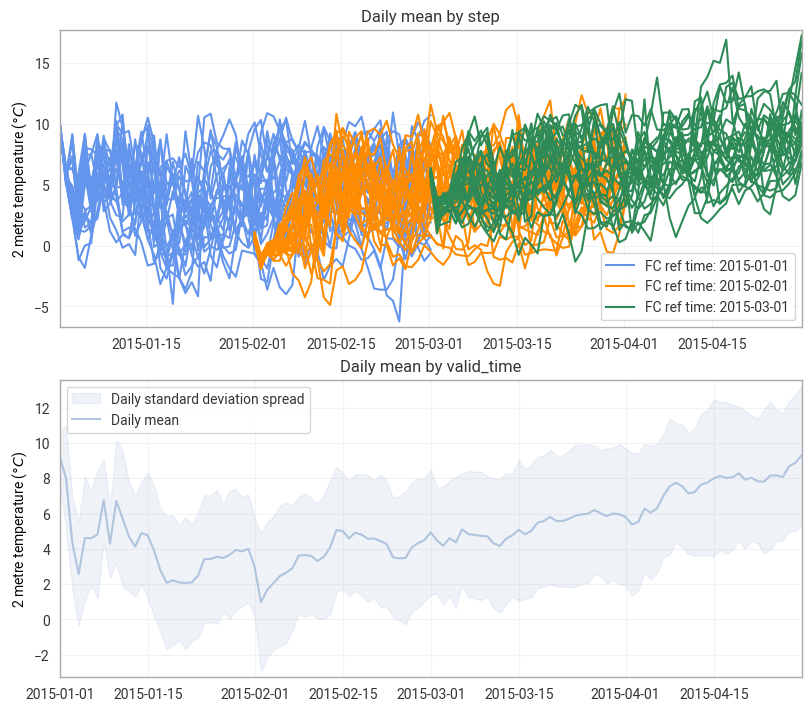

In [13]:
latitude = 52
longitude = -1.0
sel_kwargs = {"latitude": latitude, "longitude": longitude}

fig = ekp.Figure(rows=2, columns=1)

ts1 = fig.add_timeseries()
ts1.line(
    seas_daily_mean_by_step.t2m.sel(latitude=52, longitude=-1),
    x="valid_time",
    units="celsius",
    color_by="forecast_reference_time",
    colors=["cornflowerblue", "darkorange", "seagreen"],
    label="FC ref time: {forecast_reference_time:%Y-%m-%d}",
)
ts1.title("Daily mean by step")
ts1.legend()
ts1.ylabel()

ts2 = fig.add_timeseries()
upper_m = seas5_daily_mean_by_vt + seas5_daily_std_by_vt
lower_m = seas5_daily_mean_by_vt - seas5_daily_std_by_vt
ts2.fill_between(
    lower_m.sel(**sel_kwargs),
    upper_m.sel(**sel_kwargs),
    x="date",
    units="celsius",
    label="Daily standard deviation spread",
    color="lightsteelblue",
)
ts2.line(
    seas5_daily_mean_by_vt.sel(**sel_kwargs),
    x="date",
    units="celsius",
    label="Daily mean",
    color="lightsteelblue",
)
ts2.title("Daily mean by valid_time")
ts2.legend()
ts2.ylabel()


fig.show()